In [23]:
# ШАГ 1: Импортируем библиотеки
import pandas as pd
from google.colab import drive

In [24]:
# ШАГ 2: Загружаем реальные данные
drive.mount("/content/drive")
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# ШАГ 3: Анализ данных
print("Размер датасета:", df.shape)
print("Мошенников:", df['Class'].sum())
print("Процент мошенников:", round(df['Class'].mean() * 100, 2), "%")

Размер датасета: (284807, 31)
Мошенников: 492
Процент мошенников: 0.17 %


In [26]:
# ШАГ 4: Разделяем на признаки и цель
X = df.drop("Class", axis=1)
Y = df["Class"]

In [27]:
# ШАГ 5: Делим на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [28]:
# ШАГ 6: Обучаем модель Random Forest
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

RandomForestClassifier(random_state=42)

In [29]:
# ШАГ 7: Оцениваем качество модели
from sklearn.metrics import accuracy_score, recall_score
predictions = model.predict(X_test)
print("Accuracy:", accuracy_score(Y_test, predictions))
print("Recall:", recall_score(Y_test, predictions))

Accuracy: 0.9995611109160493
Recall: 0.7653061224489796


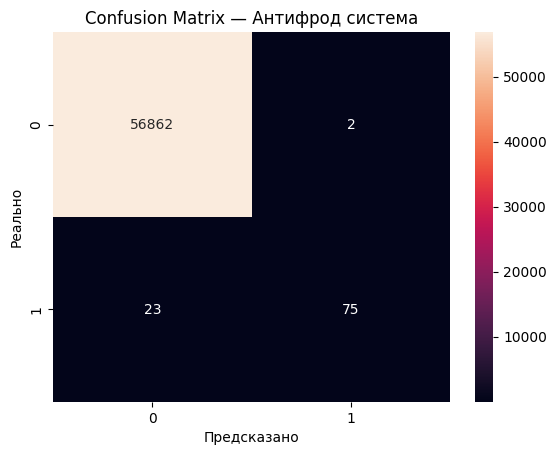

In [30]:
# ШАГ 8: Визуализируем результаты
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(Y_test, predictions)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Предсказано")
plt.ylabel("Реально")
plt.title("Confusion Matrix — Антифрод система")
plt.show()

Mounted at /content/drive
